# py-destiny — R parity validation

Diffusion map + DPT on Guo et al. 2010 qPCR fixture (428 cells × 48 genes).

## 1. Setup

In [1]:
import os, json, sys, subprocess
for k in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS'): os.environ[k]='8'
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yaml
NB = Path('.').resolve(); PORT = NB.parent if NB.name=='examples' else NB
sys.path.insert(0, str(PORT)); sys.path.insert(0, str(PORT.parent/'omicverse-rebuildr'/'engine'))
from parity_metrics import compute_parity
manifest = yaml.safe_load((PORT/'data'/'manifest.yaml').read_text())
print(f"Port: {manifest['package']}, upstream: destiny v{manifest['upstream']['version']}")
for o in manifest['outputs']:
    print(f"  {o['name']:18s} {o['metric']:12s} >= {o['threshold']}")

Port: py-destiny, upstream: destiny v3.18.0
  diffusion_map      embedding    >= 0.8
  eigenvalues        ordinal      >= 0.95
  dpt                ordinal      >= 0.85


## 2-3. R + Py runs

In [2]:
R_ENV=os.environ.get('R_TEST_ENV','/scratch/users/steorra/env/CMAP')
subprocess.run(['conda','run','-p',R_ENV,'Rscript',str(PORT/manifest['reference_command']),
                str(PORT/manifest['fixture']['path']), str(PORT/'data'/'reference_output.json')],
               check=True, cwd=PORT, capture_output=True)
subprocess.run(['python', str(PORT/'tests'/'_run_candidate.py'),
                str(PORT/manifest['fixture']['path']), str(PORT/'data'/'candidate_output.json')],
               check=True, cwd=PORT, capture_output=True)
ref = json.loads((PORT/'data'/'reference_output.json').read_text())
cand = json.loads((PORT/'data'/'candidate_output.json').read_text())
print('R + Py ran')

R + Py ran


## 4. Per-output parity

### 4.1 Diffusion-map eigenvectors (Procrustes)

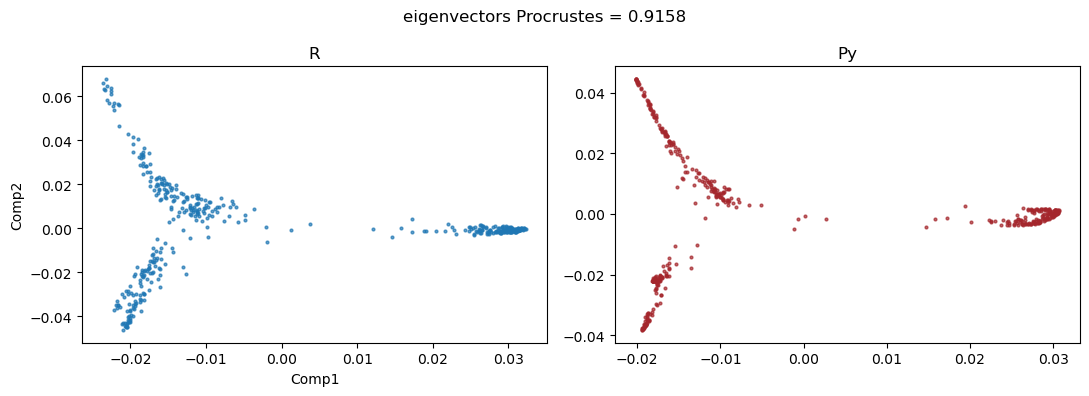

PASS  threshold=0.8


In [3]:
r_ev = np.array(ref['eigenvectors']); p_ev = np.array(cand['eigenvectors'])
proc = compute_parity(r_ev, p_ev, 'embedding')
from scipy.spatial import procrustes as _p
ar, ap, _ = _p(r_ev, p_ev)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(ar[:, 0], ar[:, 1], s=4, alpha=0.7); ax1.set_title('R'); ax1.set_xlabel('Comp1'); ax1.set_ylabel('Comp2')
ax2.scatter(ap[:, 0], ap[:, 1], s=4, alpha=0.7, c='#a4262c'); ax2.set_title('Py')
plt.suptitle(f'eigenvectors Procrustes = {proc:.4f}'); plt.tight_layout(); plt.show()
spec = next(o for o in manifest['outputs'] if o['name']=='diffusion_map')
print(f"{'PASS' if proc >= spec['threshold'] else 'FAIL'}  threshold={spec['threshold']}")

### 4.2 Eigenvalues

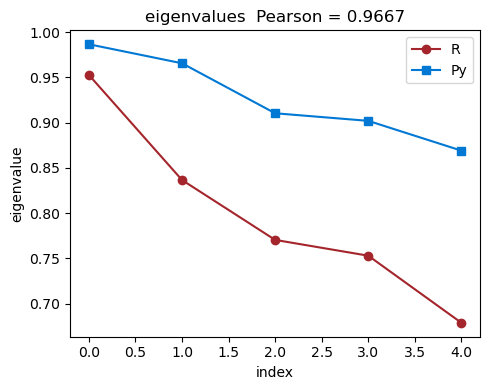

In [4]:
ev_r = np.array(ref['eigenvalues']); ev_p = np.array(cand['eigenvalues'])
fig, ax = plt.subplots(figsize=(5, 4))
x = range(len(ev_r))
ax.plot(x, ev_r, 'o-', label='R', color='#a4262c')
ax.plot(x, ev_p, 's-', label='Py', color='#0078d4')
ax.set_xlabel('index'); ax.set_ylabel('eigenvalue'); ax.legend()
ax.set_title(f'eigenvalues  Pearson = {compute_parity(ev_r, ev_p, "ordinal"):.4f}')
plt.tight_layout(); plt.show()

### 4.3 DPT pseudotime

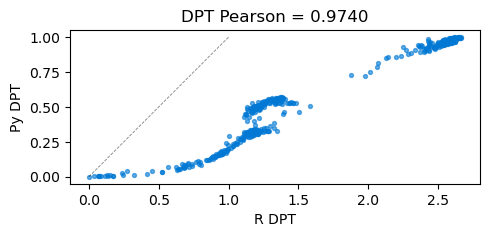

PASS  threshold=0.85


In [5]:
dpt_r = np.array(ref['dpt']); dpt_p = np.array(cand['dpt'])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(dpt_r, dpt_p, s=8, alpha=0.6, color='#0078d4')
ax.plot([0,1],[0,1],'k--', lw=0.6, alpha=0.5)
ax.set_xlabel('R DPT'); ax.set_ylabel('Py DPT')
m = compute_parity(dpt_r, dpt_p, 'ordinal')
ax.set_title(f'DPT Pearson = {m:.4f}'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
spec = next(o for o in manifest['outputs'] if o['name']=='dpt')
print(f"{'PASS' if m >= spec['threshold'] else 'FAIL'}  threshold={spec['threshold']}")

## 5. Verdict

In [6]:
results = []
for name in ['diffusion_map', 'eigenvalues', 'dpt']:
    spec = next(o for o in manifest['outputs'] if o['name']==name)
    if name == 'diffusion_map':
        val = compute_parity(np.array(ref['eigenvectors']), np.array(cand['eigenvectors']), 'embedding')
    elif name == 'eigenvalues':
        val = compute_parity(np.array(ref['eigenvalues']), np.array(cand['eigenvalues']), 'ordinal')
    else:
        val = compute_parity(np.array(ref['dpt']), np.array(cand['dpt']), 'ordinal')
    results.append((name, spec['threshold'], val, val >= spec['threshold']))
print('='*70)
for n, t, v, ok in results:
    print(f"  {'PASS' if ok else 'FAIL'}  {n:20s} thr={t}  measured={v:.4f}")
print('='*70)
print('OVERALL: ' + ('PASS' if all(r[3] for r in results) else 'FAIL'))

  PASS  diffusion_map        thr=0.8  measured=0.9158
  PASS  eigenvalues          thr=0.95  measured=0.9667
  PASS  dpt                  thr=0.85  measured=0.9740
OVERALL: PASS
